# Dataquest 2023 Preliminary: CatBoost with time, wind-vector, season and cloud-type features (submission score 0.81604)

In [4]:
!pip install -q catboost pycaret autoviz

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import catboost as cb
import xgboost as xgb
import lightgbm as lgb
from pycaret.regression import *

import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

DATA_DIR = "../data"
SUBMISSION_DIR = "../submissions"

In [6]:
ori_train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
ori_train_df.head()

,datetime,datetime_iso,time-zone,temp,visibility,d_point,feels,min_temp,max_temp,prssr,sea_level,grnd_level,hum,wind_spd,wind_deg,rain_1h,rain_3h,snow_1h,snow_3h,clouds
0,283996800,1979-01-01 00:00:00+00:00,28800,24.75 Celcius,NaN,23.89 C,25.76 C,24.28,25.22°C,1012,undetermined,NaN,95,0.82,320.0 °,zero,0,NaN,NaN,100
1,284000400,1979-01-01 01:00:00+00:00,28800,24.58 C,NaN,23.73 C,25.57 C,23.99 C,25.26 C,1012,NaN,NaN,95,0.96 m/s,338.0°,0,0,0,0,100
2,284004000,1979-01-01 02:00:00+00:00,28800,26.6 Celcius,unidentified,24.06 C,26.6 C,26.1 C,27.39,1012,NaN,undetermined,86,1.22 m/s,339.0°,0,volume:zero,NaN,NaN,99
3,284007600,1979-01-01 03:00:00+00:00,28800,27.31 Celcius,NaN,24.37 C,30.9 C,26.59,28.36 C,1012,NaN,undetermined,84,1.08 m/s,342,0.13,nol,0,NaN,94
4,284011200,1979-01-01 04:00:00+00:00,28800,27.41,NaN,25.05 C,31.54 C,26.58 C,28.31 °C,1011,NaN,undetermined,87,0.86,336.0°,0.34,nol,NaN,0,100


In [ ]:
fig = px.line(train_df[train_df["datetime"].dt.year == 2014], x="datetime", y=["rain_1h"], template = 'plotly_dark')
fig.show()

## Preprocessing

In [7]:
def clean_cols(df, is_train=True):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s')

    # function to clean unit
    def clean_unit(x):
        temp_pattern = r'-?\d+(\.\d+)?'
        regex = re.search(temp_pattern, str(x))
        return float(regex.group(0)) if regex else np.nan

    # clean unit
    df['temp'] = df['temp'].apply(clean_unit)
    df['d_point'] = df['d_point'].apply(clean_unit)
    df['feels'] = df['feels'].apply(clean_unit)
    df['min_temp'] = df['min_temp'].apply(clean_unit)
    df['max_temp'] = df['max_temp'].apply(clean_unit)
    df['prssr'] = df['prssr'].apply(clean_unit)
    df['hum'] = df['hum'].apply(clean_unit) / 100
    df['wind_spd'] = df['wind_spd'].apply(clean_unit)
    df['wind_deg'] = df['wind_deg'].apply(clean_unit)
    df['clouds'] = df['clouds'].apply(clean_unit) / 100

    # df.loc[df['hum'] > 1, 'hum'] = 1

    # clean rain_1h
    if is_train:
        df.loc[df['rain_1h'] == 'zero', 'rain_1h'] = 0
        df.loc[df['rain_1h'] == ' ', 'rain_1h'] = np.nan
        df.dropna(subset=['rain_1h'], inplace=True)
        df['rain_1h'] = df['rain_1h'].apply(clean_unit)
        df.loc[df['rain_1h'] < 0, 'rain_1h'] = 0

    # drop useless columns
    df.drop(['datetime_iso',
             'time-zone',
             'visibility',
             'sea_level',
             'grnd_level',
             'rain_3h',
             'snow_1h',
             'snow_3h'],
            axis=1, inplace=True)

    return df

In [8]:
train_df = ori_train_df.copy()
train_df = clean_cols(train_df)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,0.95,0.82,320.0,0.00,1.00
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,0.95,0.96,338.0,0.00,1.00
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,0.86,1.22,339.0,0.00,0.99
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,0.84,1.08,342.0,0.13,0.94
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,0.87,0.86,336.0,0.34,1.00


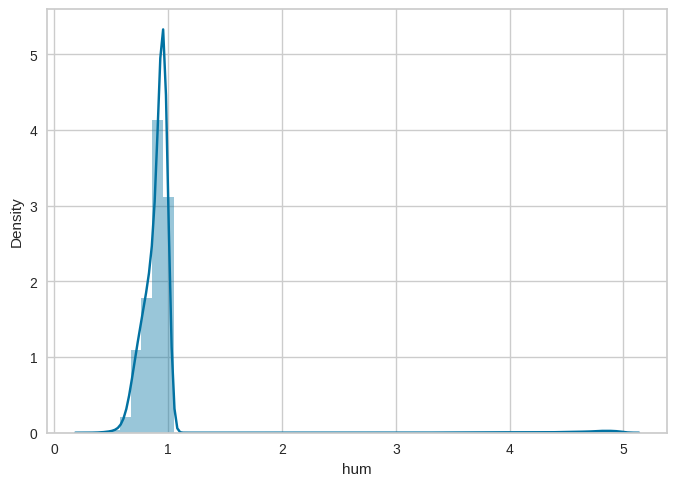

In [10]:
# plot hum distribution
sns.distplot(train_df['hum'])
plt.show()

In [11]:
print(len(train_df[train_df.hum > 1]), len(train_df))
print(len(train_df[train_df.clouds > 1]), len(train_df))

4795 320590
0 320590


In [12]:
train_df.drop(train_df[train_df.hum > 1].index, inplace=True)
print(len(train_df[train_df.hum > 1]), len(train_df))

0 315795


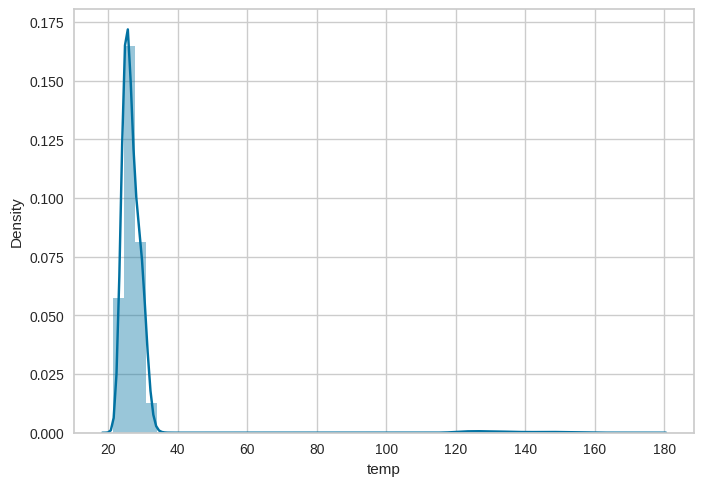

In [13]:
# plot temp distribution
sns.distplot(train_df['temp'])
plt.show()

In [14]:
print(len(train_df[train_df.temp > 100]), len(train_df))

4723 315795


In [15]:
train_df.drop(train_df[train_df.temp > 100].index, inplace=True)
print(len(train_df[train_df.temp > 100]), len(train_df))

0 311072


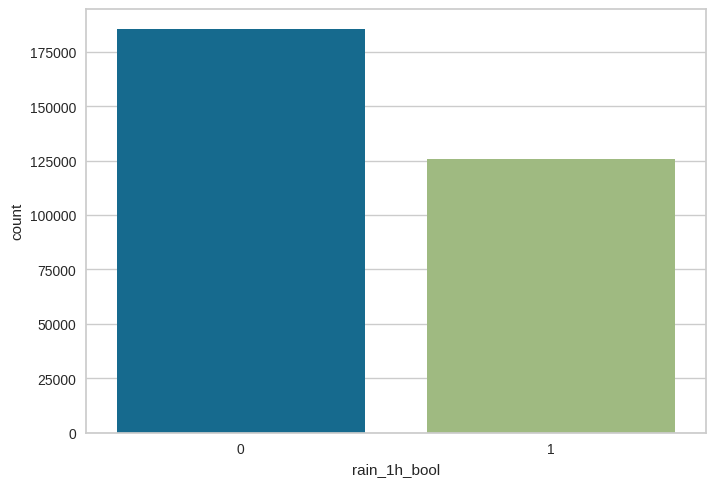

In [16]:
# plot rain_1h == 0 vs > 0
train_df['rain_1h_bool'] = train_df['rain_1h'].apply(lambda x: 1 if x > 0 else 0)
sns.countplot(x='rain_1h_bool', data=train_df)
plt.show()

## Feature Engineering

### Time Feature

In [17]:
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['week'] = train_df['datetime'].dt.week
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['dayofweek'] = train_df['datetime'].dt.dayofweek

Text(0.5, 1.0, 'Time of day signal')

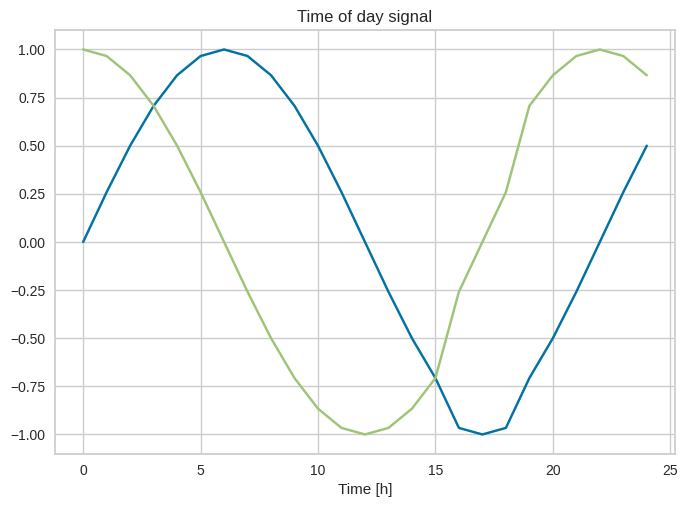

In [19]:
timestamp_s = train_df.datetime.map(pd.Timestamp.timestamp)

day = 24*60*60
year = (365.2425)*day

train_df['day_sin'] = np.sin(timestamp_s * (2 * np.pi / day))
train_df['day_cos'] = np.cos(timestamp_s * (2 * np.pi / day))
train_df['year_sin'] = np.sin(timestamp_s * (2 * np.pi / year))
train_df['year_cos'] = np.cos(timestamp_s * (2 * np.pi / year))

plt.plot(np.array(train_df['day_sin'])[:25])
plt.plot(np.array(train_df['day_cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

### Wind Vector Feature

Text(0, 0.5, 'Wind Velocity [m/s]')

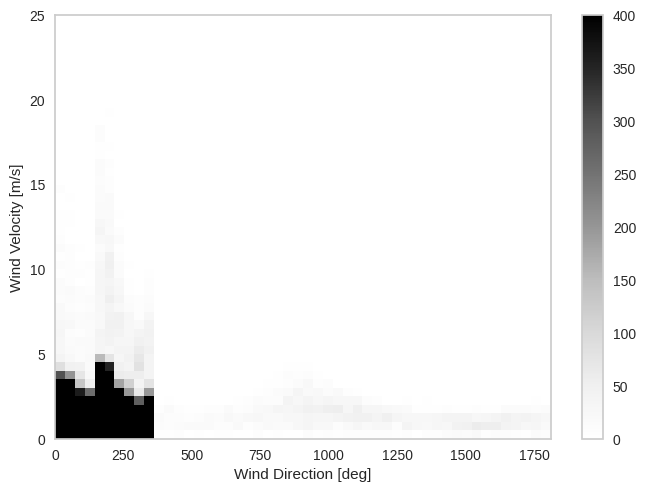

In [20]:
plt.hist2d(train_df['wind_deg'], train_df['wind_spd'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

(-24.904867452293637,
 20.79086374542152,
 -16.047027500632502,
 16.677890424529835)

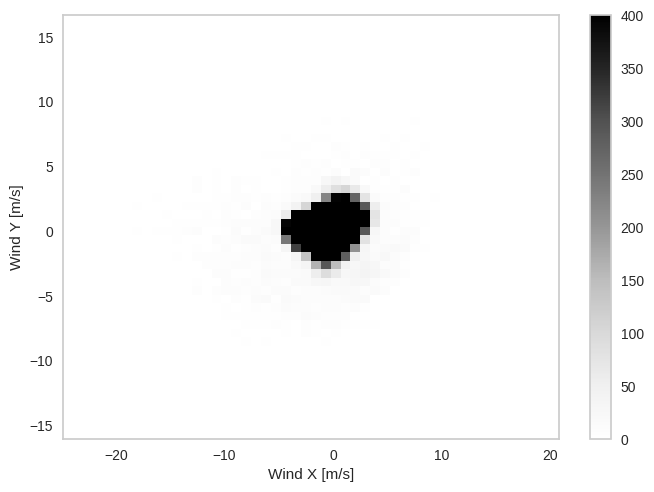

In [21]:
# convert wind speed and deg to vector
train_df['wind_x'] = train_df.wind_spd * np.cos(train_df.wind_deg * np.pi / 180)
train_df['wind_y'] = train_df.wind_spd * np.sin(train_df.wind_deg * np.pi / 180)

# plot wind_x and wind_y heatmap
plt.hist2d(train_df['wind_x'], train_df['wind_y'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

In [22]:
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,rain_1h_bool,year,month,week,day,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,wind_x,wind_y
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,0.95,0.82,320.0,0.00,1.00,0,1979,1,1,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.628156,-0.527086
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,0.95,0.96,338.0,0.00,1.00,0,1979,1,1,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,0.890097,-0.359622
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,0.86,1.22,339.0,0.00,0.99,0,1979,1,1,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.138968,-0.437209
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,0.84,1.08,342.0,0.13,0.94,1,1979,1,1,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.027141,-0.333738
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,0.87,0.86,336.0,0.34,1.00,1,1979,1,1,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,0.785649,-0.349794


### Time series

In [ ]:
train_df['series'] = np.arange(1,len(train_df)+1)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,...,day,hour,dayofweek,wind_x,wind_y,day_sin,day_cos,year_sin,year_cos,series
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,0.0095,0.82,320.0,...,1,0,0,0.628156,-0.527086,-6.132363e-13,1.000000,-0.003140,0.999995,1
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,0.0095,0.96,338.0,...,1,1,0,0.890097,-0.359622,2.588190e-01,0.965926,-0.002423,0.999997,2
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,0.0086,1.22,339.0,...,1,2,0,1.138968,-0.437209,5.000000e-01,0.866025,-0.001706,0.999999,3
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,0.0084,1.08,342.0,...,1,3,0,1.027141,-0.333738,7.071068e-01,0.707107,-0.000989,1.000000,4
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,0.0087,0.86,336.0,...,1,4,0,0.785649,-0.349794,8.660254e-01,0.500000,-0.000272,1.000000,5


### To Categorical

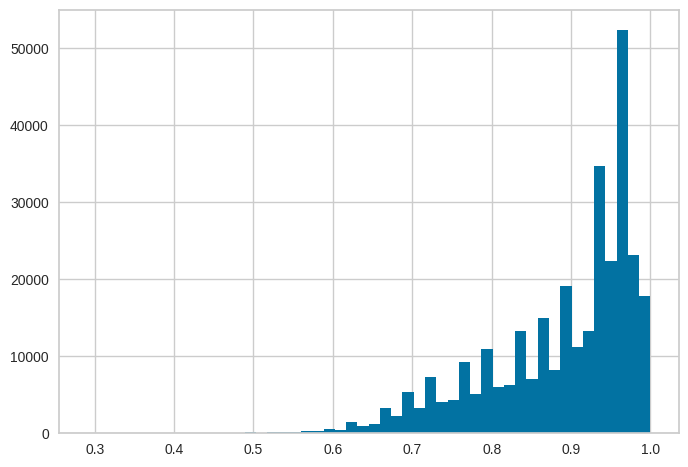

In [183]:
# plot hum distribution
plt.hist(train_df['hum'], bins=50)
plt.show()

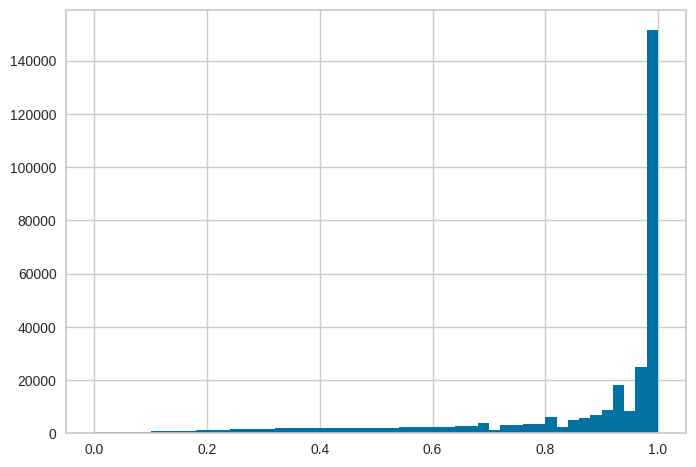

In [184]:
# plot clouds distribution
plt.hist(train_df['clouds'], bins=50)
plt.show()

In [185]:
train_df['clouds_type'] = "none"
train_df.loc[train_df.clouds > 0, 'clouds_type'] = "few"
train_df.loc[train_df.clouds > 0.10, 'clouds_type'] = "isolated"
train_df.loc[train_df.clouds > 0.25, 'clouds_type'] = "scattered"
train_df.loc[train_df.clouds > 0.50, 'clouds_type'] = "broken"
train_df.loc[train_df.clouds > 0.90, 'clouds_type'] = "overcast"

train_df.clouds_type.value_counts()

overcast     207701
broken        69105
scattered     23374
isolated       8040
few            2626
none            226
Name: clouds_type, dtype: int64

### Holiday, Season, etc

In [23]:
def create_features(df):
    # Temperature Range
    df['temp_range'] = df['max_temp'] - df['min_temp']

    # Weekend Indicator
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    # Daytime Indicator
    df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)
    # Season Indicator
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'
    df['season'] = df['month'].apply(get_season)
    import pandas as pd

    # Encode 'season' column as one-hot encoding
    season_encoded = pd.get_dummies(df['season'], prefix='season')

    # Concatenate the one-hot encoded columns with the original DataFrame
    df_encoded = pd.concat([df, season_encoded], axis=1)

    # Drop the original 'season' column
    df_encoded.drop('season', axis=1, inplace=True)

    return df_encoded

# Usage:
# Assuming you have a DataFrame called train_df
train_df = create_features(train_df)
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,rain_1h_bool,year,month,week,day,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,wind_x,wind_y,temp_range,is_weekend,is_daytime,season_Fall,season_Spring,season_Summer,season_Winter
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,0.95,0.82,320.0,0.00,1.00,0,1979,1,1,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.628156,-0.527086,0.94,0,0,0,0,0,1
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,0.95,0.96,338.0,0.00,1.00,0,1979,1,1,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,0.890097,-0.359622,1.27,0,0,0,0,0,1
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,0.86,1.22,339.0,0.00,0.99,0,1979,1,1,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.138968,-0.437209,1.29,0,0,0,0,0,1
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,0.84,1.08,342.0,0.13,0.94,1,1979,1,1,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.027141,-0.333738,1.77,0,0,0,0,0,1
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,0.87,0.86,336.0,0.34,1.00,1,1979,1,1,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,0.785649,-0.349794,1.73,0,0,0,0,0,1


## Modeling

### Binary CLassification

In [24]:
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,rain_1h_bool,year,month,week,day,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,wind_x,wind_y,temp_range,is_weekend,is_daytime,season_Fall,season_Spring,season_Summer,season_Winter
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,0.95,0.82,320.0,0.00,1.00,0,1979,1,1,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.628156,-0.527086,0.94,0,0,0,0,0,1
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,0.95,0.96,338.0,0.00,1.00,0,1979,1,1,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,0.890097,-0.359622,1.27,0,0,0,0,0,1
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,0.86,1.22,339.0,0.00,0.99,0,1979,1,1,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.138968,-0.437209,1.29,0,0,0,0,0,1
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,0.84,1.08,342.0,0.13,0.94,1,1979,1,1,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.027141,-0.333738,1.77,0,0,0,0,0,1
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,0.87,0.86,336.0,0.34,1.00,1,1979,1,1,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,0.785649,-0.349794,1.73,0,0,0,0,0,1


In [25]:
X_bc = train_df.drop(['rain_1h', 'rain_1h_bool'], axis=1)
y_bc = train_df['rain_1h_bool']

X_bc.drop([
        'datetime',
        'wind_spd',
        'wind_deg',
        # 'clouds',
        ], axis=1, inplace=True)

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

print(X_bc_train.shape, y_bc_train.shape, X_bc_test.shape, y_bc_test.shape)

(248857, 27) (248857,) (62215, 27) (62215,)


In [26]:
cbc_model = cb.CatBoostClassifier(task_type='GPU', random_state=42)
cbc_model.fit(X_bc_train, y_bc_train)

Learning rate set to 0.024888
0:	learn: 0.6846981	total: 11.5ms	remaining: 11.5s
1:	learn: 0.6768836	total: 26.1ms	remaining: 13s
2:	learn: 0.6695332	total: 36.6ms	remaining: 12.2s
3:	learn: 0.6625550	total: 46.7ms	remaining: 11.6s
4:	learn: 0.6560213	total: 59.2ms	remaining: 11.8s
5:	learn: 0.6497366	total: 70.2ms	remaining: 11.6s
6:	learn: 0.6439332	total: 80.3ms	remaining: 11.4s
7:	learn: 0.6383708	total: 91.5ms	remaining: 11.3s
8:	learn: 0.6330877	total: 102ms	remaining: 11.2s
9:	learn: 0.6280757	total: 112ms	remaining: 11.1s
10:	learn: 0.6232238	total: 128ms	remaining: 11.5s
11:	learn: 0.6187597	total: 138ms	remaining: 11.4s
12:	learn: 0.6145847	total: 148ms	remaining: 11.3s
13:	learn: 0.6104021	total: 158ms	remaining: 11.2s
14:	learn: 0.6065215	total: 168ms	remaining: 11.1s
15:	learn: 0.6026982	total: 179ms	remaining: 11s
16:	learn: 0.5992091	total: 189ms	remaining: 10.9s
17:	learn: 0.5959232	total: 199ms	remaining: 10.8s
18:	learn: 0.5928434	total: 209ms	remaining: 10.8s
19:	lea

In [27]:
y_bc_val_pred = cbc_model.predict(X_bc_test)
print(classification_report(y_bc_test, y_bc_val_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81     37210
           1       0.73      0.67      0.70     25005

    accuracy                           0.77     62215
   macro avg       0.76      0.75      0.75     62215
weighted avg       0.76      0.77      0.76     62215



### Regression

In [ ]:
train_df.shape

(311072, 32)

In [28]:
X = train_df.drop([
    'rain_1h',
    # 'rain_1h_bool'
    ], axis=1)
y = train_df['rain_1h']

X.drop([
        'datetime',
        'wind_spd',
        'wind_deg',
        # 'clouds',
        ], axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(248857, 28) (248857,) (62215, 28) (62215,)


In [29]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [187]:
# one hot clouds_type
X_train = pd.get_dummies(X_train, columns=['clouds_type'])
X_test = pd.get_dummies(X_test, columns=['clouds_type'])

X_train.head()

,temp,d_point,feels,min_temp,max_temp,prssr,hum,rain_1h_bool,year,month,week,day,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,wind_x,wind_y,temp_range,is_weekend,is_daytime,season_Fall,season_Spring,season_Summer,season_Winter,clouds_type_broken,clouds_type_few,clouds_type_isolated,clouds_type_none,clouds_type_overcast,clouds_type_scattered
321283,24.90,24.73,26.03,23.76,27.02,5085.33,0.99,0,2015,8,35,26,19,2,-9.659258e-01,0.258819,-0.813758,-0.581203,-0.843289,-1.041376,3.26,0,0,0,0,1,0,0,0,0,0,0,1
301483,25.07,24.90,26.22,24.17,26.09,1011.00,0.99,1,2013,5,21,23,19,3,-9.659258e-01,0.258819,0.625156,-0.780500,0.423935,-0.678438,1.92,0,0,0,1,0,0,0,0,0,0,1,0
162168,24.36,24.02,25.41,23.76,25.24,1010.00,0.98,1,1997,7,27,2,0,2,-1.010563e-12,1.000000,0.002903,-0.999996,0.488519,0.582194,1.48,0,0,0,0,1,0,0,0,0,0,1,0
234757,26.24,25.02,26.24,25.48,27.38,1011.00,0.93,0,2005,10,41,12,13,2,-2.588190e-01,-0.965926,-0.981751,0.190169,0.396752,1.591285,1.90,0,1,1,0,0,0,0,0,0,0,1,0
159972,26.62,24.66,26.62,25.96,27.09,1008.00,0.89,0,1997,4,14,1,12,1,1.425136e-12,-1.000000,0.999981,0.006161,1.276288,0.622487,1.13,0,1,0,1,0,0,0,0,0,0,1,0


In [30]:
cbr_model = cb.CatBoostRegressor(task_type='GPU', random_state=42)
cbr_model.fit(X_train, y_train)

Learning rate set to 0.083211
0:	learn: 0.9385949	total: 7.97ms	remaining: 7.96s
1:	learn: 0.9159244	total: 14.9ms	remaining: 7.43s
2:	learn: 0.8962633	total: 21.7ms	remaining: 7.2s
3:	learn: 0.8794890	total: 28.6ms	remaining: 7.12s
4:	learn: 0.8648627	total: 35.4ms	remaining: 7.04s
5:	learn: 0.8518647	total: 42.2ms	remaining: 7s
6:	learn: 0.8408170	total: 49.1ms	remaining: 6.96s
7:	learn: 0.8314364	total: 55.9ms	remaining: 6.93s
8:	learn: 0.8235179	total: 63.1ms	remaining: 6.94s
9:	learn: 0.8166044	total: 69.9ms	remaining: 6.92s
10:	learn: 0.8103294	total: 76.9ms	remaining: 6.91s
11:	learn: 0.8048367	total: 83.7ms	remaining: 6.89s
12:	learn: 0.8003000	total: 90.7ms	remaining: 6.89s
13:	learn: 0.7962059	total: 97.5ms	remaining: 6.87s
14:	learn: 0.7927592	total: 104ms	remaining: 6.85s
15:	learn: 0.7898466	total: 113ms	remaining: 6.93s
16:	learn: 0.7871271	total: 120ms	remaining: 6.93s
17:	learn: 0.7849303	total: 127ms	remaining: 6.91s
18:	learn: 0.7830454	total: 152ms	remaining: 7.86s
1

In [189]:
# cleaned + drop datetime, wind_spd, wind_deg, clouds + time feat [1 & 2] + wind vector feat + season feat + categorical clouds feat
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.750366200353014


In [182]:
# cleaned + drop datetime, wind_spd, wind_deg + time feat [1 & 2] + wind vector feat + season feat
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7474934308110519


In [178]:
# cleaned + drop datetime, wind_spd, wind_deg + time feat [1 & 2] + wind vector feat
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.747533737367353


In [173]:
# cleaned + drop datetime + time feat [1 & 2] + wind vector feat
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7490060511979351


In [154]:
# cleaned + drop datetime + time feat [2]
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7544663687151123


In [124]:
# cleaned + drop datetime + time feat [1]
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7539662696989592


In [99]:
# cleaned + drop datetime + time feat [1 & 2]
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.749877261048135


In [140]:
# cleaned + time feat
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.7507393500828122


In [89]:
# cleaned
y_val_pred = cbr_model.predict(X_test)
y_val_pred = [0 if x < 0 else x for x in y_val_pred]
print(rmse(y_test, y_val_pred))

0.8004684065764426


In [ ]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', tree_method='gpu_hist', random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [ ]:
y_val_pred = xgb_model.predict(X_test)
print(rmse(y_test, y_val_pred))

0.8077893456928108


In [32]:
ori_test_df = pd.read_csv(f"{DATA_DIR}/test.csv")
test_df = ori_test_df.copy()
test_df = clean_cols(test_df, is_train=False)

test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['week'] = test_df['datetime'].dt.week
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour
test_df['dayofweek'] = test_df['datetime'].dt.dayofweek

timestamp_s = test_df.datetime.map(pd.Timestamp.timestamp)

day = 24*60*60
year = (365.2425)*day

test_df['day_sin'] = np.sin(timestamp_s * (2 * np.pi / day))
test_df['day_cos'] = np.cos(timestamp_s * (2 * np.pi / day))
test_df['year_sin'] = np.sin(timestamp_s * (2 * np.pi / year))
test_df['year_cos'] = np.cos(timestamp_s * (2 * np.pi / year))

test_df['wind_x'] = test_df.wind_spd * np.cos(test_df.wind_deg * np.pi / 180)
test_df['wind_y'] = test_df.wind_spd * np.sin(test_df.wind_deg * np.pi / 180)

test_df = create_features(test_df)

test_df.drop(['datetime', 'wind_spd', 'wind_deg'], axis=1, inplace=True)

test_df.head()

,temp,d_point,feels,min_temp,max_temp,prssr,hum,clouds,year,month,week,day,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,wind_x,wind_y,temp_range,is_weekend,is_daytime,season_Fall,season_Spring,season_Summer,season_Winter
0,26.59,23.66,26.59,26.02,27.16,1009.0,0.84,0.97,2018,1,1,1,0,0,-2.389847e-12,1.000000,0.006193,0.999981,1.444482,-0.126376,1.14,0,0,0,0,0,1
1,26.51,24.92,26.51,26.06,28.04,1009.0,0.91,0.95,2018,1,1,1,1,0,2.588190e-01,0.965926,0.006910,0.999976,1.649440,-0.261246,1.98,0,0,0,0,0,1
2,28.68,25.71,34.68,28.03,29.30,1009.0,0.84,0.90,2018,1,1,1,2,0,5.000000e-01,0.866025,0.007626,0.999971,1.661392,-0.445169,1.27,0,0,0,0,0,1
3,28.84,25.25,34.51,28.52,29.08,1008.0,0.81,0.91,2018,1,1,1,3,0,7.071068e-01,0.707107,0.008343,0.999965,1.391035,-0.533968,0.56,0,0,0,0,0,1
4,29.75,24.62,35.38,29.31,30.57,1007.0,0.74,0.96,2018,1,1,1,4,0,8.660254e-01,0.500000,0.009060,0.999959,1.297677,-0.498131,1.26,0,0,0,0,0,1


In [33]:
submission_df = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

submission_df['datetime_iso'] = ori_test_df['datetime_iso']
test_df['rain_1h_bool'] = cbc_model.predict(test_df)
submission_df['rain_1h'] = cbr_model.predict(test_df)
# submission_df['rain_1h'] = cbc_model.predict(test_df)
# submission_df.loc[submission_df.rain_1h == 1, 'rain_1h'] = cbr_model.predict(test_df[submission_df.rain_1h == 1])

submission_df.loc[submission_df['rain_1h'] < 0, 'rain_1h'] = 0

# submission_df.to_csv(f"{SUBMISSION_DIR}/submission2.csv", index=False)
submission_df.to_csv(f"{SUBMISSION_DIR}/submission4.csv", index=False)

submission_df.head()

,datetime_iso,rain_1h
0,2018-01-01 00:00:00+00:00,0.000000
1,2018-01-01 01:00:00+00:00,0.000000
2,2018-01-01 02:00:00+00:00,0.000000
3,2018-01-01 03:00:00+00:00,0.712763
4,2018-01-01 04:00:00+00:00,0.000000


In [ ]:
y_val_pred = cbr_model.predict(X_test)
print(rmse(y_test, y_val_pred))

0.8061456982456116


In [ ]:
train_df.head()

,datetime,temp,d_point,feels,min_temp,max_temp,prssr,hum,wind_spd,wind_deg,rain_1h,clouds,wind_x,wind_y,year,month,week,day,hour,dayofweek,day_sin,day_cos,year_sin,year_cos,temp_range,is_weekend,is_daytime,season_Fall,season_Spring,season_Summer,season_Winter
0,1979-01-01 00:00:00,24.75,23.89,25.76,24.28,25.22,1012.0,0.95,0.82,320.0,0.00,1.00,0.628156,-0.527086,1979,1,1,1,0,0,-6.132363e-13,1.000000,-0.003140,0.999995,0.94,0,0,0,0,0,1
1,1979-01-01 01:00:00,24.58,23.73,25.57,23.99,25.26,1012.0,0.95,0.96,338.0,0.00,1.00,0.890097,-0.359622,1979,1,1,1,1,0,2.588190e-01,0.965926,-0.002423,0.999997,1.27,0,0,0,0,0,1
2,1979-01-01 02:00:00,26.60,24.06,26.60,26.10,27.39,1012.0,0.86,1.22,339.0,0.00,0.99,1.138968,-0.437209,1979,1,1,1,2,0,5.000000e-01,0.866025,-0.001706,0.999999,1.29,0,0,0,0,0,1
3,1979-01-01 03:00:00,27.31,24.37,30.90,26.59,28.36,1012.0,0.84,1.08,342.0,0.13,0.94,1.027141,-0.333738,1979,1,1,1,3,0,7.071068e-01,0.707107,-0.000989,1.000000,1.77,0,0,0,0,0,1
4,1979-01-01 04:00:00,27.41,25.05,31.54,26.58,28.31,1011.0,0.87,0.86,336.0,0.34,1.00,0.785649,-0.349794,1979,1,1,1,4,0,8.660254e-01,0.500000,-0.000272,1.000000,1.73,0,0,0,0,0,1


In [ ]:
# Define your features (X) and target variable (y)
X_train = train_df.drop(columns=['rain_1h','datetime', 'wind_spd', 'wind_deg'])
y_train = train_df['rain_1h']
# X_test = test_df  # Features for prediction
# X_train = pd.get_dummies(X_train, columns=['clouds_type'])
# X_test = pd.get_dummies(X_test, columns=['clouds_type'])

# Initialize the XGBoost regressor
xgb_model = xgb.XGBRegressor(n_estimators=30,objective='reg:squarederror', tree_method='gpu_hist', random_state=42)  # You can tune hyperparameters as needed

# Evaluate RMSE using cross-validation
rmse_scores = np.sqrt(-cross_val_score(xgb_model, X_train, y_train, scoring="neg_mean_squared_error", cv=5))

# Fit the model on the entire training dataset
xgb_model.fit(X_train, y_train)

# Predict on the test dataset
# y_pred = xgb_model.predict(X_test)

# Optionally, you can save the predictions to a DataFrame
# predictions_df = pd.DataFrame({'Predicted_Target': y_pred})

# Print the RMSE scores from cross-validation
print("Cross-Validation RMSE Scores:", rmse_scores)
print("Mean RMSE:", np.mean(rmse_scores))

Cross-Validation RMSE Scores: [0.78340353 0.78162502 0.80716021 0.85273565 0.91631174]
Mean RMSE: 0.8282472286275002


In [ ]:
data = pd.concat([X, y], axis=1)
train = data[data['year'] < 2010]
test = data[data['year'] >= 2010]

print(train.shape, test.shape)

(254695, 22) (65895, 22)


In [ ]:
s = setup(data = train, test_data = test, target = 'rain_1h', fold_strategy = 'timeseries', fold = 3, transform_target = True, use_gpu=True, session_id = 123)

,Description,Value
0,Session id,123
1,Target,rain_1h
2,Target type,Regression
3,Original data shape,"(320590, 22)"
4,Transformed data shape,"(320590, 22)"
5,Transformed train set shape,"(254695, 22)"
6,Transformed test set shape,"(65895, 22)"
7,Numeric features,21
8,Preprocess,True
9,Imputation type,simple


In [ ]:
best = compare_models(sort = 'RMSE')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.3426,0.8802,0.9379,0.0393,0.3608,0.6893,4.2733
et,Extra Trees Regressor,0.3481,0.8910,0.9437,0.0273,0.3644,0.6728,49.5967
gbr,Gradient Boosting Regressor,0.3467,0.8927,0.9445,0.0258,0.3651,0.6782,47.5433
rf,Random Forest Regressor,0.3560,0.8982,0.9475,0.0193,0.3664,0.6331,164.6933
ada,AdaBoost Regressor,0.3666,0.9248,0.9614,-0.0097,0.3769,0.6114,5.7700
lr,Linear Regression,0.3680,0.9482,0.9735,-0.0352,0.3879,0.6472,3.4667
br,Bayesian Ridge,0.3680,0.9483,0.9735,-0.0352,0.3879,0.6472,0.3300
ridge,Ridge Regression,0.3686,0.9518,0.9754,-0.0392,0.3897,0.6501,0.2200
omp,Orthogonal Matching Pursuit,0.3832,0.9873,0.9934,-0.0779,0.4062,0.6653,0.2267
lasso,Lasso Regression,0.3872,0.9931,0.9963,-0.0843,0.4088,0.6837,0.2367


In [ ]:
y_val_pred = predict_model(best, test).prediction_label
print(rmse(test.rain_1h, y_val_pred))

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.3923,1.0422,1.0209,0.0109,0.3921,0.6889


1.0208929552583528
